In [1]:
'''
Let's import useful and "standard" packages.
Not all packages will be used in the short course. It is my habit to import them
ahead of time.
'''

import numpy as np # numpy is a powerful package for numeric calculation, we rename it as "np"
import sys, os # these are system related packages
import pickle # pickle is a cute package to save and load your custom data
import shutil # for high-level file operations
import scipy, sklearn, skimage, math # these are useful packages for scientific computing, machine learning, image processing, and math calculation
import matplotlib.pyplot as plt # this is a powerful package for visualization, e.g., curves, bar charts, histograms, and various visualizations.
import cv2 # this is a powerful package for computer vision
from pathlib import Path
from PIL import Image
from sklearn.metrics import confusion_matrix

In [2]:
'''
Let's import the famous PyTorch package, supporting deep learning.
It is convenient to give short names for useful functions inside PyTorch
'''
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision
from torchvision import datasets, models, transforms

In [3]:
# Set the global random seed for reproducibility
np.random.seed(0) 


# load the train&val sets

In [4]:
filename_train = 'cls_train.pkl'
filename_val = 'cls_val.pkl'

In [5]:
with open(filename_train, 'rb') as file:
    trainset_info = pickle.load(file)

with open(filename_val, 'rb') as file:
    valset_info = pickle.load(file)

In [6]:
train_labellist = trainset_info['train_labellist']
val_labellist = valset_info['val_labellist']

numClasses = max(train_labellist)+1

In [7]:
train_imgs = []
val_imgs = []

for curname in trainset_info['train_imgpathlist']:
    im = skimage.io.imread(curname)
    train_imgs += [im.astype(np.float32)]

for curname in valset_info['val_imgpathlist']:
    im = skimage.io.imread(curname)
    val_imgs += [im.astype(np.float32)]

# load a pretrained deep neural network and extract deep features

In [8]:
# set device, which gpu to use.
device ='cpu'
if torch.cuda.is_available(): 
    device='cuda:0'
print(device)

cuda:0


In [9]:
torch.cuda.device_count()
torch.cuda.empty_cache()


In [10]:
resnet18_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
feature_extractor = nn.Sequential(*list(resnet18_model.children())[:-1])

In [11]:
print(feature_extractor)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [12]:
feature_extractor.eval()
feature_extractor.to(device);

In [13]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [14]:
trainFea = []
for i in range(len(train_imgs)):
    im = train_imgs[i] / 255.0
    im = data_transform(im)
    fea = feature_extractor(im.to(device).unsqueeze(0))
    trainFea += [fea]

In [15]:
valFea = []
for i in range(len(val_imgs)):
    im = val_imgs[i] / 255.0
    im = data_transform(im)
    fea = feature_extractor(im.to(device).unsqueeze(0))
    valFea += [fea]

# Nearest Neighbor Classifier over the deep features

In [16]:
def NearestNeighbor(Database, test_img):
    distanceList = []
    for i in range(len(Database)):
        curExample = Database[i]
        tmp = (curExample - test_img)**2
        distanceList += [tmp.sum().detach().cpu().numpy()]
    return distanceList

In [17]:
predList = []
for i in range(len(valFea)):
    cur_fea = valFea[i]
    distanceList = NearestNeighbor(trainFea, cur_fea)
    targetIdx = np.argmin(distanceList)
    predLabel = train_labellist[targetIdx]
    predList += [predLabel]

    if i%10==0:
        print('%d/%d...' %(i, len(val_imgs)))

0/172...
10/172...
20/172...
30/172...
40/172...
50/172...
60/172...
70/172...
80/172...
90/172...
100/172...
110/172...
120/172...
130/172...
140/172...
150/172...
160/172...
170/172...


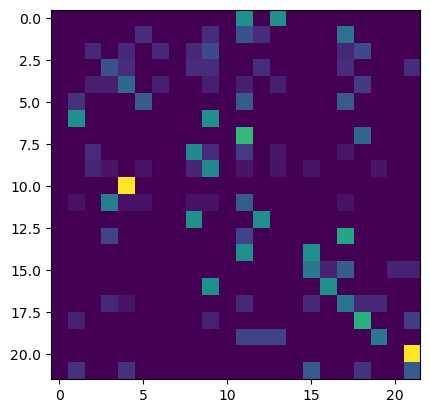

In [18]:
conf = sklearn.metrics.confusion_matrix(val_labellist, predList, normalize='true')

plt.imshow(conf)

In [19]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())

mean accuracy: 0.242


# Support Vector Machine (SVM)

In [20]:
from sklearn import svm

In [21]:
for i in range(len(trainFea)):
    fea = trainFea[i]
    fea = fea.squeeze().detach().cpu().numpy()
    trainFea[i] = fea

for i in range(len(valFea)):
    fea = valFea[i]
    fea = fea.squeeze().detach().cpu().numpy()
    valFea[i] = fea

In [22]:
trainFea = np.asarray(trainFea).squeeze()
valFea = np.asarray(valFea).squeeze()

train_labellist = np.asarray(train_labellist)
val_labellist = np.asarray(val_labellist)

print(trainFea.shape)
print(train_labellist.shape)

print(valFea.shape)
print(val_labellist.shape)

(678, 512)
(678,)
(172, 512)
(172,)


In [23]:
clf = svm.SVC(kernel='linear', verbose=True, max_iter=50)
clf.fit(trainFea, train_labellist)

[LibSVM]*.WARN: libsvm Solver reached max_iter
optimization finished, #iter = 50
obj = -0.076898, rho = 0.614583
nSV = 23, nBSV = 0
.WARN: libsvm Solver reached max_iter
optimization finished, #iter = 50
obj = -0.079380, rho = 0.827672
nSV = 29, nBSV = 0
.WARN: libsvm Solver reached max_iter
optimization finished, #iter = 50
obj = -0.050919, rho = 1.190961
nSV = 21, nBSV = 0
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 50
obj = -0.065000, rho = 1.420867
nSV = 25, nBSV = 0
.WARN: libsvm Solver reached max_iter
optimization finished, #iter = 50
obj = -0.081722, rho = 1.546386
nSV = 28, nBSV = 0
.*.*
optimization finished, #iter = 36
obj = -0.053284, rho = 0.262300
nSV = 14, nBSV = 0
.*
optimization finished, #iter = 33
obj = -0.042333, rho = 0.048980
nSV = 14, nBSV = 0
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 50
obj = -0.086297, rho = 0.081967
nSV = 34, nBSV = 0
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 50
obj = 

/home/gpuadmin/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVC(kernel='linear', max_iter=50, verbose=True)

In [24]:
predList = clf.predict(valFea)

In [25]:
conf = sklearn.metrics.confusion_matrix(val_labellist, predList, normalize='true')


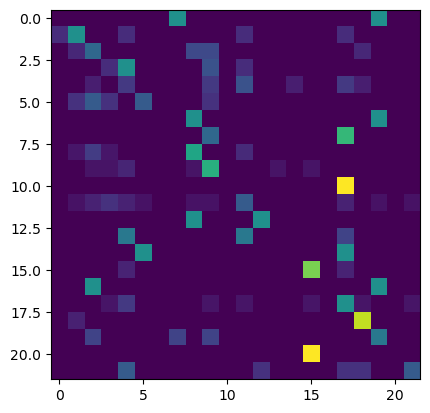

In [26]:
plt.imshow(conf)

In [27]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())

mean accuracy: 0.287
